## Lab 1 - Intro to Behavioral TV Data
# Name: Korinnyi Zakhar
# Group: KM-43

### Setup

In [16]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

DATA = kagglehub.dataset_download("shkarupylomaxim/adtech-lab1-tv-panel/versions/2")
       # Colab and Kaggle
programs = pd.read_parquet(f"{DATA}/programs.parquet")
viewings = pd.read_parquet(f"{DATA}/viewings.parquet")
daily_weights = pd.read_parquet(f"{DATA}/daily_weights.parquet")
viewer_attributes = pd.read_parquet(f"{DATA}/viewer_attributes.parquet")
attributes = pd.read_parquet(f"{DATA}/attributes.parquet")

Using Colab cache for faster access to the 'adtech-lab1-tv-panel' dataset.


### Task 1.1 - Panel and universe

In [17]:
# unique counts
num_telecasts = programs['telecast_id'].nunique()
num_programs = programs['program_name'].nunique()
num_networks = programs['network_code'].nunique()

# filter H and persons (R, L)
households_data = daily_weights[daily_weights['resp_type'] == 'H']
persons_data = daily_weights[(daily_weights['resp_type'] == 'R') | (daily_weights['resp_type'] == 'L')]

# total unique in panel
unique_households = households_data['respondent_id'].nunique()
unique_persons = persons_data['respondent_id'].nunique()

# daily in-tab averages
households_per_day = households_data.groupby('broadcast_date')['respondent_id'].count()
persons_per_day = persons_data.groupby('broadcast_date')['respondent_id'].count()

avg_households_intab = round(households_per_day.mean())
avg_persons_intab = round(persons_per_day.mean())

# projected US population
weights_hh_per_day = households_data.groupby('broadcast_date')['weight'].sum()
weights_persons_per_day = persons_data.groupby('broadcast_date')['weight'].sum()

avg_us_households_m = weights_hh_per_day.mean() / 1000000
avg_us_persons_m = weights_persons_per_day.mean() / 1000000

print("Telecasts:", num_telecasts)
print("Programs:", num_programs)
print("Networks:", num_networks)
print("Households in panel:", unique_households)
print("Persons in panel:", unique_persons)
print("Households in-tab, average day:", avg_households_intab)
print("Persons in-tab, average day:", avg_persons_intab)
print(f"US TV households represented, average day (M): {avg_us_households_m:.2f}")
print(f"US persons represented, average day (M): {avg_us_persons_m:.2f}")

Telecasts: 5841
Programs: 246
Networks: 10
Households in panel: 4254
Persons in panel: 10210
Households in-tab, average day: 3878
Persons in-tab, average day: 9269
US TV households represented, average day (M): 125.80
US persons represented, average day (M): 317.28


**Answer:** The `viewer_attributes` file contains a list of all members of the panel. However, the `daily_weights` table (in-tab data) includes only those whose meters were working and sending data on certain days. Some people may simply not have active accounts in October, or their meters may have broken.

### Task 1.2 - Average audience by hour of day

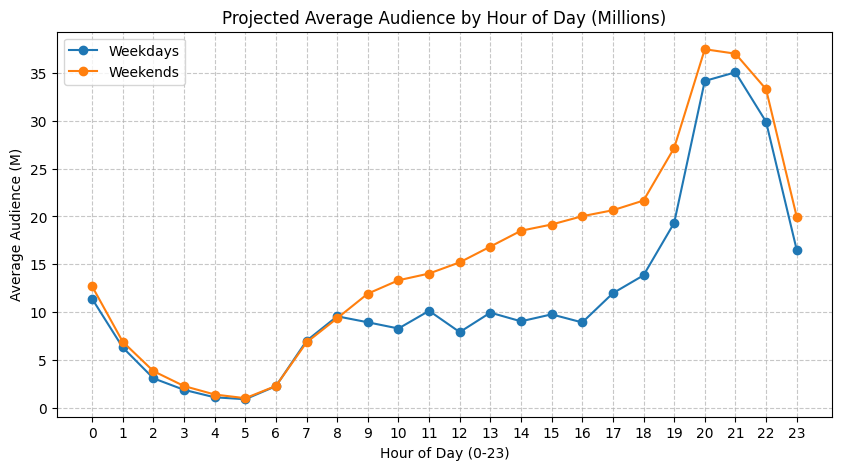

Peak hour, weekdays: 21
Peak hour, weekends: 20


In [18]:
# filter only persons (R, L)
persons_viewings = viewings[viewings['resp_type'].isin(['R', 'L'])].copy()

# count weekdays and weekends
unique_dates = pd.to_datetime(daily_weights['broadcast_date'].unique())
num_weekends = (unique_dates.dayofweek >= 5).sum()
num_weekdays = (unique_dates.dayofweek < 5).sum()

# assign broadcast date (starts at 06:00)
persons_viewings['broadcast_date'] = (persons_viewings['start_ts'] - pd.Timedelta(hours=6)).dt.date
persons_viewings['is_weekend'] = pd.to_datetime(persons_viewings['broadcast_date']).dt.dayofweek >= 5

# initialize minutes counters
weekday_mins_by_hour = {h: 0.0 for h in range(24)}
weekend_mins_by_hour = {h: 0.0 for h in range(24)}

# split sessions at hour boundaries
for start, end, weight, is_we in zip(persons_viewings['start_ts'], persons_viewings['end_ts'], persons_viewings['weight'], persons_viewings['is_weekend']):
    current_time = start
    while current_time < end:
        next_hour = current_time.replace(minute=0, second=0) + pd.Timedelta(hours=1)
        chunk_end = min(end, next_hour)

        mins = (chunk_end - current_time).total_seconds() / 60.0

        if is_we:
            weekend_mins_by_hour[current_time.hour] += mins * weight
        else:
            weekday_mins_by_hour[current_time.hour] += mins * weight

        current_time = chunk_end

# calculate average audience in millions
hours = list(range(24))
weekday_avg_audience = [(weekday_mins_by_hour[h] / 60 / num_weekdays) / 1_000_000 for h in hours]
weekend_avg_audience = [(weekend_mins_by_hour[h] / 60 / num_weekends) / 1_000_000 for h in hours]

plt.figure(figsize=(10, 5))
plt.plot(hours, weekday_avg_audience, label='Weekdays', marker='o')
plt.plot(hours, weekend_avg_audience, label='Weekends', marker='o')
plt.title('Projected Average Audience by Hour of Day (Millions)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Audience (M)')
plt.xticks(hours)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# peak hours
peak_weekday = hours[weekday_avg_audience.index(max(weekday_avg_audience))]
peak_weekend = hours[weekend_avg_audience.index(max(weekend_avg_audience))]

print("Peak hour, weekdays:", peak_weekday)
print("Peak hour, weekends:", peak_weekend)

**Answer:** Viewer behavior is very different on weekends. The daytime audience is much larger than on weekdays, since people stay home. Also, on weekends, the trend line rises more slowly throughout the day, and there isn’t such a big jump in activity during prime time (evening hours) as there is on weekdays, when people return from work together.


### Task 1.3 - Session length

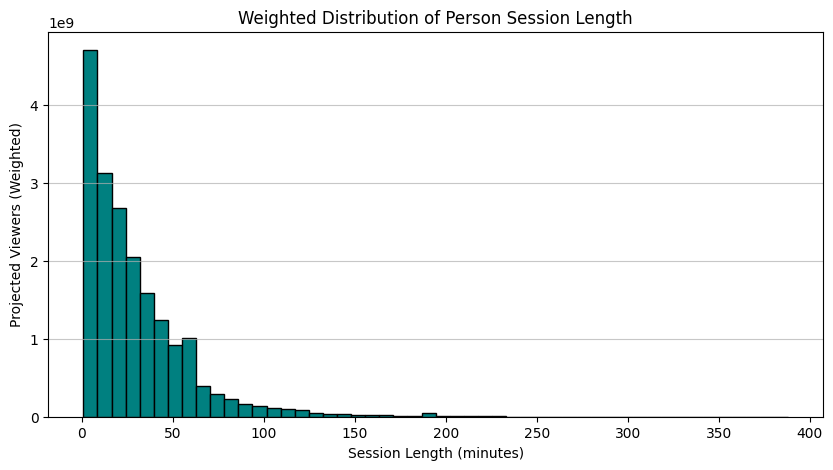

Session length, weighted mean (min): 29.37
Session length, weighted median (min): 21.0


In [19]:
# calculate session length in minutes
persons_viewings['session_length'] = (persons_viewings['end_ts'] - persons_viewings['start_ts']).dt.total_seconds() / 60.0

# plot weighted histogram
plt.figure(figsize=(10, 5))
plt.hist(persons_viewings['session_length'], bins=50, weights=persons_viewings['weight'], color='teal', edgecolor='black')
plt.title('Weighted Distribution of Person Session Length')
plt.xlabel('Session Length (minutes)')
plt.ylabel('Projected Viewers (Weighted)')
plt.grid(axis='y', alpha=0.7)
plt.show()

# weighted mean
weighted_mean = (persons_viewings['session_length'] * persons_viewings['weight']).sum() / persons_viewings['weight'].sum()

# weighted median
sorted_viewings = persons_viewings.sort_values('session_length')
cum_weights = sorted_viewings['weight'].cumsum()
total_weight = sorted_viewings['weight'].sum()

median_idx = (cum_weights >= total_weight / 2).idxmax()
weighted_median = sorted_viewings.loc[median_idx, 'session_length']

print("Session length, weighted mean (min):", round(weighted_mean, 2))
print("Session length, weighted median (min):", round(weighted_median, 2))

**Answer:** The weighted average and the median are different because the session duration has an asymmetric pattern (with a long “tail” on the right). Most sessions are short, which pulls the median down, but the small number of very long sessions (for example, when the TV is left on in the background for hours) seriously boosts the arithmetic average. For a presentation to a client, it is better to use the median, since it more realistically shows typical viewer behavior without being changed by extreme exceptions.

### Task 2 - Program reach curve

Telecasts of the program: 23
Average household rating (%): 3.2
Average P2+ rating (%): 1.6
Average projected audience (M): 4.93
Final reach P2+ (%): 9.9
Final reach A18-34 (%): 2.6
Final reach A18-49 (%): 4.4


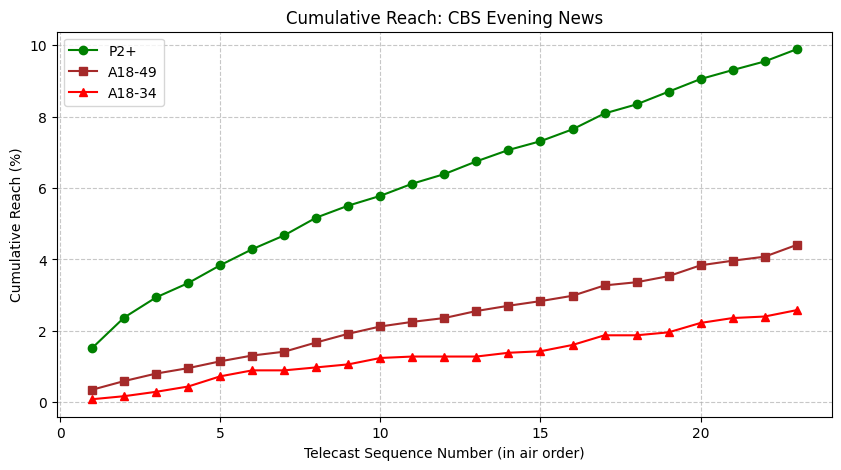

In [20]:
# filter CBS Evening News telecasts and sort by air time
cbs_news = programs[(programs['network_code'] == 'CBS') & (programs['program_name'] == 'CBS Evening News')]
cbs_news = cbs_news.sort_values('start_ts').reset_index(drop=True)

# get age demographics (attr_id 300)
ages = viewer_attributes[viewer_attributes['attr_id'] == 300][['respondent_id', 'value']]
ages = ages.rename(columns={'value': 'age'})

# calculate monthly average weights for persons (R, L)
persons_intab = daily_weights[daily_weights['resp_type'].isin(['R', 'L'])]
monthly_avg_weights = persons_intab.groupby('respondent_id')['weight'].mean().reset_index()
monthly_avg_weights = monthly_avg_weights.rename(columns={'weight': 'avg_weight'})

# merge weights with age
persons_demo = pd.merge(monthly_avg_weights, ages, on='respondent_id', how='left')

# calculate reach denominators (total avg weight per group)
base_p2_plus = persons_demo['avg_weight'].sum()
base_a18_34 = persons_demo[(persons_demo['age'] >= 18) & (persons_demo['age'] <= 34)]['avg_weight'].sum()
base_a18_49 = persons_demo[(persons_demo['age'] >= 18) & (persons_demo['age'] <= 49)]['avg_weight'].sum()

# filter CBS viewings for speed
cbs_viewings = viewings[viewings['network_code'] == 'CBS']
cbs_hh_viewings = cbs_viewings[cbs_viewings['resp_type'] == 'H']
cbs_p_viewings = cbs_viewings[cbs_viewings['resp_type'].isin(['R', 'L'])]

hh_ratings = []
p2_ratings = []
proj_audiences_m = []

cum_viewers_p2 = set()
cum_viewers_a18_34 = set()
cum_viewers_a18_49 = set()

reach_p2 = []
reach_a18_34 = []
reach_a18_49 = []

# iterate through telecasts
for index, telecast in cbs_news.iterrows():
    b_date = telecast['broadcast_date']
    start_t = telecast['start_ts']
    end_t = telecast['end_ts']

    # daily in-tab base for ratings
    daily_in_tab = daily_weights[daily_weights['broadcast_date'] == b_date]
    daily_hh_base = daily_in_tab[daily_in_tab['resp_type'] == 'H']['weight'].sum()
    daily_p_base = daily_in_tab[daily_in_tab['resp_type'].isin(['R', 'L'])]['weight'].sum()

    # get viewers who watched >= 1 min
    def get_valid_viewers(df):
        overlap = df[(df['start_ts'] < end_t) & (df['end_ts'] > start_t)].copy()
        if overlap.empty: return set()

        overlap['overlap_start'] = overlap['start_ts'].clip(lower=start_t)
        overlap['overlap_end'] = overlap['end_ts'].clip(upper=end_t)
        overlap['duration_sec'] = (overlap['overlap_end'] - overlap['overlap_start']).dt.total_seconds()

        valid = overlap[overlap['duration_sec'] >= 60]['respondent_id'].unique()
        return set(valid)

    # get valid viewers for this telecast
    hh_viewers = get_valid_viewers(cbs_hh_viewings)
    p_viewers = get_valid_viewers(cbs_p_viewings)

    # sum daily weights for watched viewers
    hh_watched_weight = daily_in_tab[(daily_in_tab['respondent_id'].isin(hh_viewers)) & (daily_in_tab['resp_type'] == 'H')]['weight'].sum()
    p_watched_weight = daily_in_tab[(daily_in_tab['respondent_id'].isin(p_viewers)) & (daily_in_tab['resp_type'].isin(['R', 'L']))]['weight'].sum()

    # calculate ratings
    hh_ratings.append((hh_watched_weight / daily_hh_base) * 100)
    p2_ratings.append((p_watched_weight / daily_p_base) * 100)
    proj_audiences_m.append(p_watched_weight / 1000000)

    # update cumulative viewers
    cum_viewers_p2.update(p_viewers)

    # filter viewers by age group
    viewers_demo = persons_demo[persons_demo['respondent_id'].isin(p_viewers)]
    a18_34_viewers = viewers_demo[(viewers_demo['age'] >= 18) & (viewers_demo['age'] <= 34)]['respondent_id'].tolist()
    a18_49_viewers = viewers_demo[(viewers_demo['age'] >= 18) & (viewers_demo['age'] <= 49)]['respondent_id'].tolist()

    cum_viewers_a18_34.update(a18_34_viewers)
    cum_viewers_a18_49.update(a18_49_viewers)

    # calculate cumulative reach
    cum_weight_p2 = persons_demo[persons_demo['respondent_id'].isin(cum_viewers_p2)]['avg_weight'].sum()
    cum_weight_a18_34 = persons_demo[persons_demo['respondent_id'].isin(cum_viewers_a18_34)]['avg_weight'].sum()
    cum_weight_a18_49 = persons_demo[persons_demo['respondent_id'].isin(cum_viewers_a18_49)]['avg_weight'].sum()

    reach_p2.append((cum_weight_p2 / base_p2_plus) * 100)
    reach_a18_34.append((cum_weight_a18_34 / base_a18_34) * 100)
    reach_a18_49.append((cum_weight_a18_49 / base_a18_49) * 100)

print("Telecasts of the program:", len(cbs_news))
print(f"Average household rating (%): {sum(hh_ratings) / len(hh_ratings):.1f}")
print(f"Average P2+ rating (%): {sum(p2_ratings) / len(p2_ratings):.1f}")
print(f"Average projected audience (M): {sum(proj_audiences_m) / len(proj_audiences_m):.2f}")
print(f"Final reach P2+ (%): {reach_p2[-1]:.1f}")
print(f"Final reach A18-34 (%): {reach_a18_34[-1]:.1f}")
print(f"Final reach A18-49 (%): {reach_a18_49[-1]:.1f}")

plt.figure(figsize=(10, 5))
x_axis = range(1, len(cbs_news) + 1)
plt.plot(x_axis, reach_p2, label='P2+', marker='o', color='green')
plt.plot(x_axis, reach_a18_49, label='A18-49', marker='s', color='brown')
plt.plot(x_axis, reach_a18_34, label='A18-34', marker='^', color='red')
plt.title('Cumulative Reach: CBS Evening News')
plt.xlabel('Telecast Sequence Number (in air order)')
plt.ylabel('Cumulative Reach (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Answer:** Cumulative reach continues to grow, despite stable ratings for each episode, because the audience watching the news each day is never exactly the same group of people. Some watch the Monday episode, others watch the Wednesday episode. Each new broadcast adds a certain number of new, unique viewers who haven’t watched the program yet this month. The program reaches the general P2+ audience best, while its reach among younger age groups (A18-34 and A18-49) is much lower. This is completely logical and agrees with reality - traditional network evening news programs have historically had an “older” audience.

### Task 3 - Program frequency

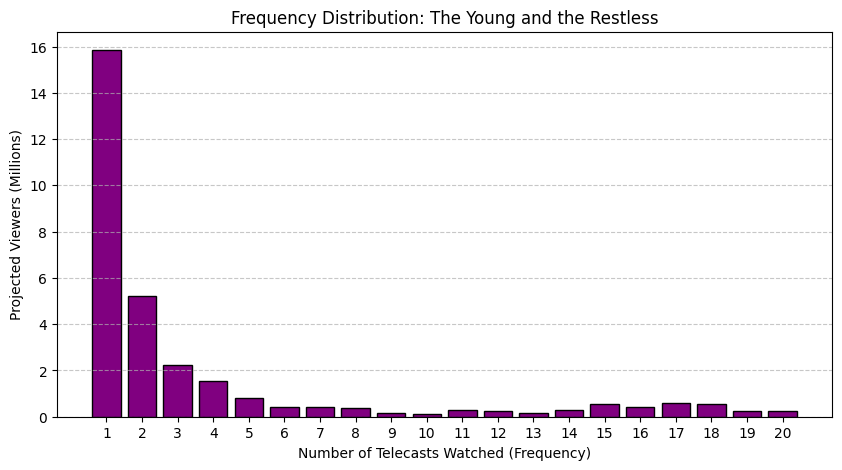

Projected viewers (M): 30.80
Average frequency (weighted): 3.6
Median frequency (weighted): 1.0
Share of views from the most loyal viewers: 0.704


In [21]:
# get yr telecasts on CBS
yr_telecasts = programs[(programs['network_code'] == 'CBS') & (programs['program_name'] == 'The Young and the Restless')]

# track frequency per viewer
viewer_frequencies = {}

for index, telecast in yr_telecasts.iterrows():
    start_t = telecast['start_ts']
    end_t = telecast['end_ts']

    # filter persons viewing during telecast
    overlap = cbs_p_viewings[(cbs_p_viewings['start_ts'] < end_t) & (cbs_p_viewings['end_ts'] > start_t)].copy()

    if not overlap.empty:
        overlap['overlap_start'] = overlap['start_ts'].clip(lower=start_t)
        overlap['overlap_end'] = overlap['end_ts'].clip(upper=end_t)
        overlap['duration_sec'] = (overlap['overlap_end'] - overlap['overlap_start']).dt.total_seconds()

        # keep viewers who watched >= 1 minute
        valid_viewers = overlap[overlap['duration_sec'] >= 60]['respondent_id'].unique()

        for viewer in valid_viewers:
            if viewer in viewer_frequencies:
                viewer_frequencies[viewer] += 1
            else:
                viewer_frequencies[viewer] = 1

# convert to dataframe
freq_df = pd.DataFrame(list(viewer_frequencies.items()), columns=['respondent_id', 'frequency'])

# merge with monthly average weights
freq_df = pd.merge(freq_df, monthly_avg_weights, on='respondent_id', how='left')

# projected viewers
projected_viewers_m = freq_df['avg_weight'].sum() / 1000000

# weighted average frequency
total_views = (freq_df['frequency'] * freq_df['avg_weight']).sum()
avg_frequency = total_views / freq_df['avg_weight'].sum()

# weighted median frequency
sorted_freq = freq_df.sort_values('frequency')
cum_weights = sorted_freq['avg_weight'].cumsum()
median_idx = (cum_weights >= freq_df['avg_weight'].sum() / 2).idxmax()
median_frequency = sorted_freq.loc[median_idx, 'frequency']

# 80th percentile loyal viewers
p80_idx = (cum_weights >= freq_df['avg_weight'].sum() * 0.80).idxmax()
p80_threshold = sorted_freq.loc[p80_idx, 'frequency']

loyal_viewers = freq_df[freq_df['frequency'] >= p80_threshold]
loyal_views = (loyal_viewers['frequency'] * loyal_viewers['avg_weight']).sum()
loyal_share = loyal_views / total_views

dist_df = freq_df.groupby('frequency')['avg_weight'].sum() / 1000000

plt.figure(figsize=(10, 5))
plt.bar(dist_df.index, dist_df.values, color='purple', edgecolor='black')
plt.title('Frequency Distribution: The Young and the Restless')
plt.xlabel('Number of Telecasts Watched (Frequency)')
plt.ylabel('Projected Viewers (Millions)')
plt.xticks(range(1, int(freq_df['frequency'].max()) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Projected viewers (M): {projected_viewers_m:.2f}")
print(f"Average frequency (weighted): {avg_frequency:.1f}")
print(f"Median frequency (weighted): {median_frequency:.1f}")
print(f"Share of views from the most loyal viewers: {loyal_share:.3f}")

**Answer:** The average frequency is an unfair and incorrect indicator because, as noted in Lecture 1, “the average can lie.” The frequency distribution is typically heavy-tailed. Most people watch only 1–2 episodes, which pushes the median to the left, but a small group of extremely loyal viewers (who have watched almost all episodes) seriously boosts the average. Therefore, the average frequency creates the false impression that the typical viewer watches the series more often than is actually the fact.

### Task 4 - Networks by age and gender

In [22]:
# extract sex attribute (201=Male, 202=Female)
sex_data = viewer_attributes[viewer_attributes['attr_id'].isin([201, 202])][['respondent_id', 'attr_id']]
sex_data = sex_data.rename(columns={'attr_id': 'sex'})

# merge full demographics
full_demo = pd.merge(persons_demo, sex_data, on='respondent_id', how='left')

# calculate viewing duration in minutes
p_viewings = viewings[viewings['resp_type'].isin(['R', 'L'])].copy()
p_viewings['duration_min'] = (p_viewings['end_ts'] - p_viewings['start_ts']).dt.total_seconds() / 60.0

# merge viewings with demographics
viewings_demo = pd.merge(p_viewings, full_demo, on='respondent_id', how='inner')

# calculate projected minutes
viewings_demo['proj_minutes'] = viewings_demo['duration_min'] * viewings_demo['avg_weight']

# assign demographic group
def get_demo_group(row):
    age = row['age']
    sex = row['sex']
    if pd.isna(age) or pd.isna(sex): return 'Unknown'

    prefix = 'M' if sex == 201 else 'W'
    if 18 <= age <= 34: return f"{prefix}18-34"
    elif 35 <= age <= 54: return f"{prefix}35-54"
    elif age >= 55: return f"{prefix}55+"
    return 'Other'

# apply grouping
viewings_demo['demo_group'] = viewings_demo.apply(get_demo_group, axis=1)

# list target demographic groups
target_groups = ['M18-34', 'W18-34', 'M35-54', 'W35-54', 'M55+', 'W55+']

# sum projected minutes by network and demo group
network_demo_mins = viewings_demo.groupby(['network_code', 'demo_group'])['proj_minutes'].sum().unstack(fill_value=0)

# get top 5 networks for each group
for group in target_groups:
    top5 = network_demo_mins[group].sort_values(ascending=False).head(5)
    print(f"\nTop 5 for {group}:")
    for rank, (net, mins) in enumerate(top5.items(), 1):
        print(f"  {rank}. {net}: {mins:,.0f} mins")

# calculate 18-34 share of minutes (weighted)
mins_18_34_proj = network_demo_mins['M18-34'] + network_demo_mins['W18-34']
total_mins_proj = viewings_demo.groupby('network_code')['proj_minutes'].sum()
share_18_34_proj = mins_18_34_proj / total_mins_proj

# raw/unweighted 18-34
network_demo_raw = viewings_demo.groupby(['network_code', 'demo_group'])['duration_min'].sum().unstack(fill_value=0)
mins_18_34_raw = network_demo_raw['M18-34'] + network_demo_raw['W18-34']
total_mins_raw = viewings_demo.groupby('network_code')['duration_min'].sum()
share_18_34_raw = mins_18_34_raw / total_mins_raw

# combine into dataframe and sort
shares_df = pd.DataFrame({
    'Weighted Share': share_18_34_proj,
    'Raw Share': share_18_34_raw
}).sort_values('Weighted Share', ascending=False)

print("\n18-34 share of minutes per network, weighted and raw:")
print(shares_df.map(lambda x: f"{x:.3f}"))

# identify youngest and oldest networks
youngest_net = shares_df.index[0]
oldest_net = shares_df.index[-1]

print("\nYoungest network:", youngest_net)
print("Oldest network:", oldest_net)


Top 5 for M18-34:
  1. FOX: 4,391,816,903 mins
  2. NBC: 3,913,091,567 mins
  3. CBS: 3,042,084,547 mins
  4. ABC: 3,009,648,988 mins
  5. FX: 1,474,890,634 mins

Top 5 for W18-34:
  1. FOX: 4,578,054,242 mins
  2. NBC: 4,529,993,393 mins
  3. ABC: 3,507,677,498 mins
  4. CBS: 2,810,381,190 mins
  5. FX: 1,383,699,358 mins

Top 5 for M35-54:
  1. FOX: 12,811,127,258 mins
  2. NBC: 10,993,148,270 mins
  3. ABC: 9,038,890,384 mins
  4. CBS: 8,137,025,253 mins
  5. FX: 2,370,720,219 mins

Top 5 for W35-54:
  1. NBC: 11,645,648,496 mins
  2. FOX: 11,168,041,848 mins
  3. ABC: 9,441,910,716 mins
  4. CBS: 8,164,382,643 mins
  5. HGTV: 3,051,679,710 mins

Top 5 for M55+:
  1. CBS: 38,276,388,658 mins
  2. NBC: 34,260,891,102 mins
  3. FOX: 30,865,426,396 mins
  4. ABC: 30,774,812,654 mins
  5. FNC: 27,910,904,449 mins

Top 5 for W55+:
  1. CBS: 47,131,360,071 mins
  2. NBC: 41,394,472,580 mins
  3. ABC: 38,823,666,209 mins
  4. FOX: 36,908,821,579 mins
  5. FNC: 31,450,553,983 mins

18-34 s

**Answer:** The difference comes from the fact that a real sample (panel) is never perfect. Certain groups of people (such as older adults) are more likely to participate in research, so they are overrepresented in the raw data, while young people are underrepresented. Weights correct this problem. If you show a client the raw data, they’ll get a wrong picture that shows only the structure of the panel itself, not the actual proportions of the U.S. population.

**Bonus answer:** Even if a network has the oldest audience on average, it can still be highly valuable to a brand. First, thanks to its high total volume, it can reach more young people in absolute numbers than a specialized youth channel. Second, this represents “underpriced attention” - the cost per mille (CPM) for reaching a young audience on an older channel can be significantly cheaper than on channels where all competitors place their ads.